## Train VAE

Goal: Train VAE on the car racing task 

In [9]:
import json
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

from world_models.models.vae import VAE

torch.manual_seed(0)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", device)

cwd = Path.cwd().resolve()
repo_root = next(
    p for p in (cwd, *cwd.parents)
    if (p / "src" / "world_models").is_dir()
    and (p / "pyproject.toml").is_file()
)

dataset_dir = (
    repo_root / "data"
    / "carracing_pilot_legacy_v1_20260910_185047_641885"
)
manifest = json.loads(
    (dataset_dir / "manifest.json").read_text()
)
assert manifest["status"] == "complete"

run_id = datetime.now().strftime("%Y%m%d_%H%M%S_%f")
run_dir = repo_root / "runs" / f"vae_pilot_{run_id}"
run_dir.mkdir(parents=True, exist_ok=False)

Device: mps


In [10]:
class EpisodeFrames(Dataset):
    def __init__(self, dataset_dir, manifest, split):
        chunks = []

        for record in manifest["episodes"]:
            if record["split"] != split:
                continue

            with np.load(dataset_dir / record["file"]) as episode:
                frames = episode["observations"]
                assert frames.dtype == np.uint8
                assert frames.shape[1:] == (64, 64, 3)
                chunks.append(frames.copy())

        if not chunks:
            raise ValueError(f"No episodes for split: {split}")

        self.frames = np.concatenate(chunks, axis=0)

    def __len__(self):
        return len(self.frames)

    def __getitem__(self, index):
        # Saved images are already preprocessed.
        return (
            torch.from_numpy(self.frames[index])
            .permute(2, 0, 1)
            .float()
            / 255.0
        )


train_data = EpisodeFrames(dataset_dir, manifest, "train")
val_data = EpisodeFrames(dataset_dir, manifest, "validation")

train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True,
    num_workers=0,
    generator=torch.Generator().manual_seed(0),
)
val_loader = DataLoader(
    val_data,
    batch_size=64,
    shuffle=False,
    num_workers=0,
)

print("Training frames:", len(train_data))
print("Validation frames:", len(val_data))

Training frames: 16016
Validation frames: 4004


In [11]:
def paper_vae_loss(reconstruction, target, mu, logvar):
    reconstruction_per_image = (
        (reconstruction - target).square()
        .flatten(start_dim=1)
        .sum(dim=1)
    )

    kl_per_image = -0.5 * (
        1 + logvar - mu.square() - logvar.exp()
    ).sum(dim=1)

    kl_floor = 0.5 * mu.shape[1]
    effective_kl = kl_per_image.clamp_min(kl_floor)

    loss = (reconstruction_per_image + effective_kl).mean()

    metrics = {
        "loss": loss.detach().item(),
        "reconstruction": reconstruction_per_image.mean().detach().item(),
        "kl_raw": kl_per_image.mean().detach().item(),
    }
    return loss, metrics

In [12]:
vae = VAE(latent_dim=32).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-4)

history = []
best_val = float("inf")

In [13]:
def run_epoch(loader, training):
    vae.train(training)

    totals = {
        "loss": 0.0,
        "reconstruction": 0.0,
        "kl_raw": 0.0,
    }
    count = 0

    with torch.set_grad_enabled(training):
        for images in loader:
            images = images.to(device)
            reconstruction, mu, logvar = vae(images)

            loss, metrics = paper_vae_loss(
                reconstruction, images, mu, logvar
            )

            if not torch.isfinite(loss):
                raise RuntimeError("Non-finite VAE loss.")

            if training:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

            batch_size = images.shape[0]
            count += batch_size
            for name in totals:
                totals[name] += metrics[name] * batch_size

    return {name: value / count for name, value in totals.items()}


for _ in range(5):
    epoch = len(history) + 1

    train_metrics = run_epoch(train_loader, training=True)
    val_metrics = run_epoch(val_loader, training=False)

    history.append({
        "epoch": epoch,
        "train": train_metrics,
        "validation": val_metrics,
    })

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": vae.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "latent_dim": 32,
        "dataset_dir": str(dataset_dir),
        "dataset_manifest": manifest,
        "loss_config": {
            "reconstruction": "sum_squared_error_per_image",
            "kl_tolerance": 0.5,
        },
        "history": history,
    }

    torch.save(checkpoint, run_dir / "last.pt")

    if val_metrics["loss"] < best_val:
        best_val = val_metrics["loss"]
        torch.save(checkpoint, run_dir / "best.pt")

    (run_dir / "history.json").write_text(
        json.dumps(history, indent=2)
    )

    print(
        f"Epoch {epoch:02d} | "
        f"train={train_metrics['loss']:.2f} | "
        f"val={val_metrics['loss']:.2f} | "
        f"val reconstruction={val_metrics['reconstruction']:.2f} | "
        f"val raw KL={val_metrics['kl_raw']:.2f}",
        flush=True,
    )

Epoch 01 | train=432.95 | val=171.08 | val reconstruction=134.78 | val raw KL=34.61
Epoch 02 | train=133.94 | val=107.14 | val reconstruction=90.14 | val raw KL=16.43
Epoch 03 | train=100.41 | val=85.89 | val reconstruction=69.24 | val raw KL=16.54
Epoch 04 | train=81.33 | val=71.81 | val reconstruction=54.75 | val raw KL=16.81
Epoch 05 | train=71.21 | val=68.75 | val reconstruction=50.95 | val raw KL=17.37


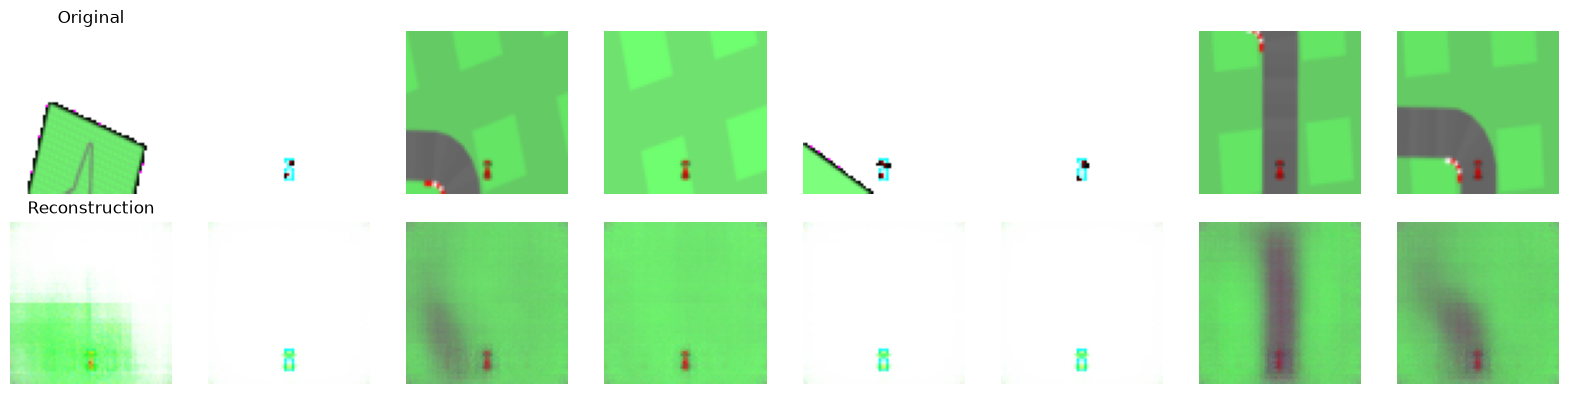

Checkpoints and results: /Users/cedric/Repos/world-models-reproduction/runs/vae_pilot_20260910_190359_481752


In [14]:
indices = np.linspace(0, len(val_data) - 1, 8, dtype=int)
images = torch.stack([val_data[i] for i in indices]).to(device)

vae.eval()
with torch.no_grad():
    mu, _ = vae.encode(images)
    reconstructed = vae.decode(mu)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for column in range(8):
    original = images[column].cpu().permute(1, 2, 0).numpy()
    decoded = reconstructed[column].cpu().permute(1, 2, 0).numpy()

    axes[0, column].imshow(original)
    axes[1, column].imshow(decoded)

    axes[0, column].axis("off")
    axes[1, column].axis("off")

axes[0, 0].set_title("Original")
axes[1, 0].set_title("Reconstruction")

plt.tight_layout()
fig.savefig(run_dir / "reconstructions.png", dpi=150)
plt.show()

print("Checkpoints and results:", run_dir)